In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
import pandas as pd
import h5py

import jax.numpy as jnp
from jesterTOV.inference.flows.flow import Flow
from jesterTOV.utils import redshift_to_luminosity_distance

events = pd.read_csv('../../eos_inference/wide_ETL/events.dat', sep=" ")
events_narrow_ETT = pd.read_csv("../../eos_inference/narrow_ETT/events.dat", sep=" ")

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

(array([6., 3., 6., 8., 6., 2., 1., 2., 2., 3.]),
 array([1.2147153 , 1.28973318, 1.36475106, 1.43976894, 1.51478682,
        1.5898047 , 1.66482258, 1.73984047, 1.81485835, 1.88987623,
        1.96489411]),
 <BarContainer object of 10 artists>)

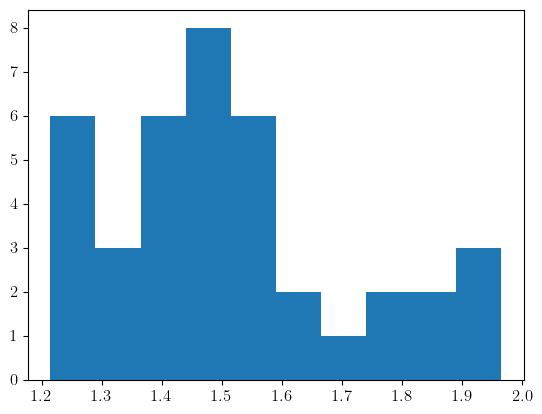

In [14]:
plt.hist(events['mass_1_source'])

In [2]:
hyperposterior = dict()
with h5py.File("./cosmo_inference/outdir/results.h5") as f:

    for key in ["H0", "Omega0"]:
        hyperposterior[key] = f["posterior"]["parameters"][key][:]
    hyperposterior['log_prob'] = f["posterior"]["log_prob"][:]



em problematic:  5
gw_problematic:  12


FileNotFoundError: [Errno 2] No such file or directory: '../../eos_inference/wide_ETL/gw_posteriors/source_35/posterior_mm.npz'

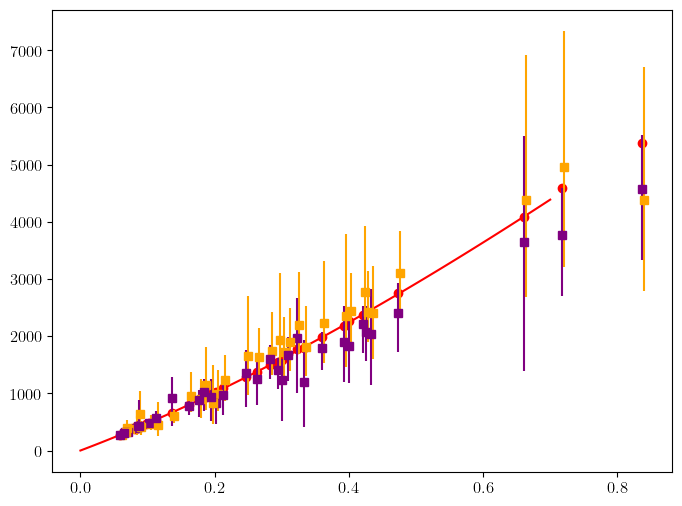

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

quantiles_gw = np.zeros(events.shape[0])
quantiles_em = np.zeros(events.shape[0])

z_arr = np.linspace(0, 0.7, 100)
dL_arr = redshift_to_luminosity_distance(z_arr)
ax.plot(z_arr, dL_arr, color="red")

for src in range(events.shape[0]):
    ax.scatter(events.loc[src, "redshift_measured"], events.loc[src, "luminosity_distance"], color="red")

    posterior_gw = np.load(f"../../eos_inference/wide_ETL/gw_posteriors/source_{src}/posterior_mm.npz")
    posterior_em = np.load(f"../../eos_inference/wide_ETL/em_posteriors/source_{src}/posterior.npz")
    quantiles_gw[src] = np.mean(events.loc[src, "luminosity_distance"] >= posterior_gw["luminosity_distance"])
    quantiles_em[src] = np.mean(events.loc[src, "luminosity_distance"] >= posterior_em["luminosity_distance"])

    lower_em, median_em, upper_em = np.quantile(posterior_em["luminosity_distance"], [1/events.shape[0], 0.5, 1-1/events.shape[0]])
    ax.errorbar(events.loc[src, "redshift_measured"]+0.003, median_em, ([median_em-lower_em], [upper_em-median_em]), color="orange", fmt="s")

    lower_gw, median_gw, upper_gw = np.quantile(posterior_gw["luminosity_distance"], [1/events.shape[0], 0.5, 1-1/events.shape[0]])
    ax.errorbar(events.loc[src, "redshift_measured"], median_gw, ([median_gw-lower_gw], [upper_gw-median_gw]), color="purple", fmt="s")


    if events.loc[src, "luminosity_distance"] < lower_em or events.loc[src, "luminosity_distance"] > upper_em:
        print("em problematic: ", src)
    if events.loc[src, "luminosity_distance"] < lower_gw or events.loc[src, "luminosity_distance"] > upper_gw:
        print("gw_problematic: ", src)


for j in range(1000):
    z_arr = np.linspace(0, 0.7, 100)
    dL_arr = redshift_to_luminosity_distance(z_arr, H0=hyperposterior["H0"][j], Omega0=hyperposterior["Omega0"][j])
    ax.plot(z_arr, dL_arr, color="grey", alpha=0.1)


ax.set_xlabel("$z$")
ax.set_ylabel("$d_L$ [Mpc]")
#ax.set_yscale("log")


Text(0, 0.5, '$d_L$ [Mpc]')

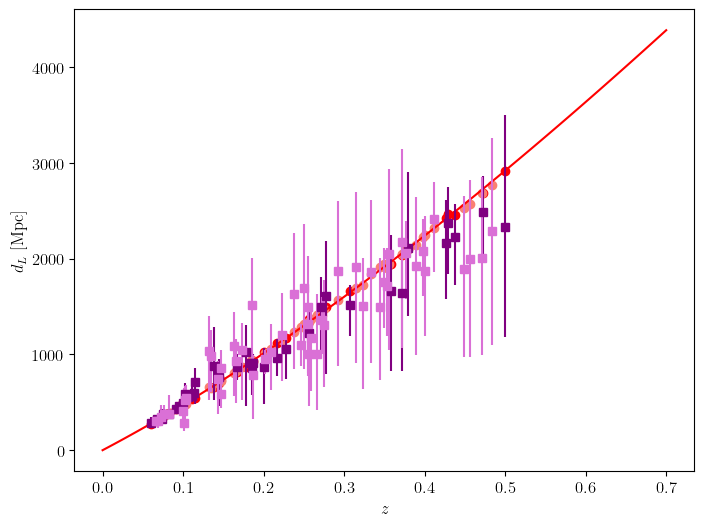

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

width_gw = np.zeros(events.shape[0])
width_gw_narrow_ett = np.zeros(events_narrow_ETT.shape[0])

z_arr = np.linspace(0, 0.7, 100)
dL_arr = redshift_to_luminosity_distance(z_arr)
ax.plot(z_arr, dL_arr, color="red")

for src in range(events.shape[0]):
    ax.scatter(events.loc[src, "redshift_measured"], events.loc[src, "luminosity_distance"], color="red")

    posterior_gw = np.load(f"../../eos_inference/wide_ETL/gw_posteriors/source_{src}/posterior_mm.npz")
    lower_gw, median_gw, upper_gw = np.quantile(posterior_gw["luminosity_distance"], [0.025, 0.5, 0.975])

    ax.errorbar(events.loc[src, "redshift_measured"], median_gw, ([median_gw-lower_gw], [upper_gw-median_gw]), color="purple", fmt="s")
    width_gw[src] = upper_gw - lower_gw


for src in range(events_narrow_ETT.shape[0]):
    ax.scatter(events_narrow_ETT.loc[src, "redshift_measured"], events_narrow_ETT.loc[src, "luminosity_distance"], color="salmon")

    posterior_gw = np.load(f"../../eos_inference/narrow_ETT/gw_posteriors/source_{src}/posterior_mm.npz")
    lower_gw, median_gw, upper_gw = np.quantile(posterior_gw["luminosity_distance"], [0.025, 0.5, 0.975])

    ax.errorbar(events_narrow_ETT.loc[src, "redshift_measured"], median_gw, ([median_gw-lower_gw], [upper_gw-median_gw]), color="orchid", fmt="s")
    width_gw_narrow_ett[src] = upper_gw - lower_gw


ax.set_xlabel("$z$")
ax.set_ylabel("$d_L$ [Mpc]")
#ax.set_yscale("log")


(array([ 4.,  6.,  4., 10.,  6.,  6.,  5.,  5.,  2.,  2.]),
 array([0.2493689 , 0.35599289, 0.46261688, 0.56924087, 0.67586486,
        0.78248885, 0.88911285, 0.99573684, 1.10236083, 1.20898482,
        1.31560881]),
 [<matplotlib.patches.Polygon at 0x7f474c4b0890>])

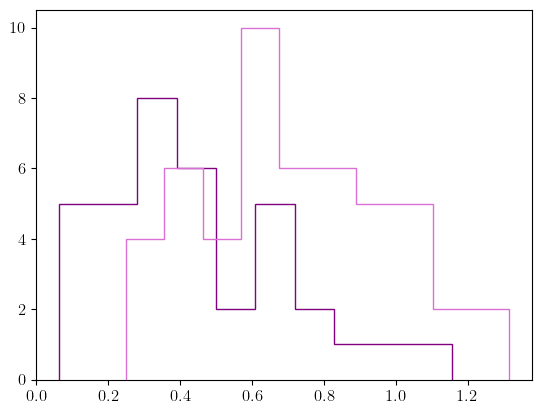

In [27]:
plt.hist(width_gw / events["luminosity_distance"], histtype="step", color="purple")
plt.hist(width_gw_narrow_ett / events_narrow_ETT["luminosity_distance"], histtype="step", color="orchid")

In [24]:
np.sort(width_gw / events["luminosity_distance"])

array([0.06180575, 0.06263354, 0.0740021 , 0.07615667, 0.14962872,
       0.22279918, 0.22857577, 0.23386413, 0.2526316 , 0.2651177 ,
       0.29564979, 0.32188017, 0.32894547, 0.337392  , 0.34291556,
       0.34435145, 0.34705147, 0.36390864, 0.41997656, 0.42328505,
       0.42621957, 0.42792484, 0.44225085, 0.48768506, 0.53629155,
       0.57482561, 0.64123639, 0.66904931, 0.68260085, 0.68887886,
       0.71411067, 0.73133363, 0.79325794, 0.92543414, 0.96701659,
       1.15615627])

In [25]:
np.sort(width_gw_narrow_ett / events_narrow_ETT["luminosity_distance"])

array([0.2493689 , 0.26630632, 0.33604365, 0.35190991, 0.36116121,
       0.37457858, 0.38337421, 0.40455565, 0.42023145, 0.43046002,
       0.47367922, 0.48242848, 0.49825526, 0.55962047, 0.5852    ,
       0.61166397, 0.63371504, 0.64744982, 0.65121638, 0.65747634,
       0.6648144 , 0.66560602, 0.66582584, 0.6717145 , 0.69279883,
       0.7166415 , 0.71936256, 0.75256773, 0.7710311 , 0.78245684,
       0.78587104, 0.78777216, 0.80481078, 0.81535563, 0.81836155,
       0.8553773 , 0.90895609, 0.91738067, 0.92524297, 0.93109124,
       0.97742362, 1.00232107, 1.01246378, 1.05849367, 1.08744998,
       1.10000424, 1.14982864, 1.15713424, 1.22946787, 1.31560881])